In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/eishatuzzuhra/ai-usage-and-impact-on-students-and-professionals/AI_Usage_and_Impact_on_Students_and_Professionals.csv


# Load the Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/eishatuzzuhra/ai-usage-and-impact-on-students-and-professionals/AI_Usage_and_Impact_on_Students_and_Professionals.csv')

In [3]:
df.head()

,User_ID,Age,Gender,Country,User_Type,Education_Level,Profession,Monthly_Income,AI_Tool,AI_Purpose,AI_Usage_Hours_Per_Day,Tasks_Performed,Monthly_AI_Cost,Productivity_Score,Accuracy_Rating,Satisfaction_Score,Time_Saved_Hours_Per_Week,Work_or_Study_Hours_Per_Day,Would_Recommend
0,U0269,30,Male,United Kingdom,Professional,Master's,Business Analyst,5421,ChatGPT,Office Work,2 hrs,Data analysis using AI-powered analytics tools...,NaN,5.3,4.0,7.0,3.9,7.3,Yes
1,U0217,30,Male,United States,Professional,Bachelor's,Customer Support Specialist,8903,ChatGPT,Customer Support,5.7,Resolving customer inquiries using AI chatbot ...,0,9.9,3.0,9.0,11.4,8.4 hrs,Yes
2,U0152,17,Male,Canada,Student,NaN,Computer Science Student,402,Chat GPT,Coding,1 hrs,NaN,20,3.2,2.0,4.0,5.2,6.7,No
3,U0264,35,FEMALE,Brazil,Professional,Bachelor's,Desenvolvedora de Software / Software Developer,1367,Meta AI,Coding,1.7,"Usar GitHub Copilot para autocompletar código,...",20,5.6,4.0,5.0,6.4,9.6,Maybe
4,U0263,19,Female,Canada,Student,Undergraduate,Biology Student,438,Perplexity AI,NaN,4.1,Using AI to generate study summaries for exam ...,0,4.7,4.0,7.0,9.2,6.2,Yes


In [4]:
df.tail()

,User_ID,Age,Gender,Country,User_Type,Education_Level,Profession,Monthly_Income,AI_Tool,AI_Purpose,AI_Usage_Hours_Per_Day,Tasks_Performed,Monthly_AI_Cost,Productivity_Score,Accuracy_Rating,Satisfaction_Score,Time_Saved_Hours_Per_Week,Work_or_Study_Hours_Per_Day,Would_Recommend
295,U0066,NaN,Female,United States,Professional,Bachelor's,NaN,8255,Microsoft Copilot,NaN,1.8,"Code debugging with AI pair programming tools,...",0,1.8,3.0,4.0,NaN,12.2,No
296,U0094,43,Male,Nigeria,Professional,Diploma,Multimedia Content Producer,NaN,ChatGPT,Content Creation,1.2,Writing blog articles with AI writing assistan...,0,4.7,3.0,NaN,1,10.9,No
297,U0136,48,Male,Brazil,Professional,Diploma,Desenvolvedor de Sistemas (Systems Developer),544,Google Gemini,Coding,5.5,"Code debugging and optimization with AI tools,...",0,7.8,4.0,7.0,11.5,8.4,Yes
298,U0002,31,Female,Pakistan,Professional,Diploma,Junior Software Developer,448,ChatGPT,Coding,0.7 hrs,"Automated code generation using AI assistants,...",0,4.3,3.0,4.0,1.7,9.5,No
299,U0130,36 yrs,Male,United States,Professional,Diploma,Software Developer,6766,Chat GPT,Coding,2.8,"Debugging code with AI-assisted analysis, gene...",0,5.4,4.0,7.0,6.2,8.2,Yes


In [5]:
df.sample(5)

,User_ID,Age,Gender,Country,User_Type,Education_Level,Profession,Monthly_Income,AI_Tool,AI_Purpose,AI_Usage_Hours_Per_Day,Tasks_Performed,Monthly_AI_Cost,Productivity_Score,Accuracy_Rating,Satisfaction_Score,Time_Saved_Hours_Per_Week,Work_or_Study_Hours_Per_Day,Would_Recommend
188,U0072,23,Female,India,Student,NaN,Computer Science Student,50,Grammarly,Coding,9.8,"Debugging code with AI assistance, generating ...",$0,9.1,4.0,9.0,15.8,5.2,Yes
191,U0133,20,Female,Nigeria,Student,Master's,Biomedical Engineering Student,135,Claude,Research,1.6,Literature review analysis using AI research t...,30,4.5,4.0,6.0,3.5,NaN,Maybe
239,U0065,NaN,male,United Kingdom,Student,Bachelor's,Mechanical Engineering Student,334,ChatGPT,Studying,4.1,"Explaining complex physics concepts, solving d...",20,5.2,3.0,7.0,8.4,5.9,Yes
189,U0245,63,Female,India,Professional,High School,NaN,1320,Claude,Office Work,1.7,"Email management and scheduling, document prep...",NaN,5.2,3.0,6.0,3.5 hrs,9.4,Yes
119,U0161,25,F,Canada,Professional,master's degree,AI Customer Support Specialist,6171,Google Gemini,Customer Support,1.9,Respond to customer inquiries using AI chatbot...,0,3.7,4.0,5.0,0.8,7.6,Maybe


In [6]:
# To check the shape and size
print("Rows, Columns", df.shape)
print("Total cells", df.size)
print("Column names", df.columns.tolist)

Rows, Columns (300, 19)
Total cells 5700
Column names <bound method IndexOpsMixin.tolist of Index(['User_ID', 'Age', 'Gender', 'Country', 'User_Type', 'Education_Level',
       'Profession', 'Monthly_Income', 'AI_Tool', 'AI_Purpose',
       'AI_Usage_Hours_Per_Day', 'Tasks_Performed', 'Monthly_AI_Cost',
       'Productivity_Score', 'Accuracy_Rating', 'Satisfaction_Score',
       'Time_Saved_Hours_Per_Week', 'Work_or_Study_Hours_Per_Day',
       'Would_Recommend'],
      dtype='object')>


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   User_ID                      300 non-null    object 
 1   Age                          277 non-null    object 
 2   Gender                       290 non-null    object 
 3   Country                      290 non-null    object 
 4   User_Type                    300 non-null    object 
 5   Education_Level              287 non-null    object 
 6   Profession                   285 non-null    object 
 7   Monthly_Income               290 non-null    object 
 8   AI_Tool                      289 non-null    object 
 9   AI_Purpose                   287 non-null    object 
 10  AI_Usage_Hours_Per_Day       293 non-null    object 
 11  Tasks_Performed              282 non-null    object 
 12  Monthly_AI_Cost              288 non-null    object 
 13  Productivity_Score  

In [8]:
df.isnull().sum()

User_ID                         0
Age                            23
Gender                         10
Country                        10
User_Type                       0
Education_Level                13
Profession                     15
Monthly_Income                 10
AI_Tool                        11
AI_Purpose                     13
AI_Usage_Hours_Per_Day          7
Tasks_Performed                18
Monthly_AI_Cost                12
Productivity_Score             16
Accuracy_Rating                15
Satisfaction_Score              7
Time_Saved_Hours_Per_Week      10
Work_or_Study_Hours_Per_Day     9
Would_Recommend                 5
dtype: int64

Oops! So many null values

In [9]:
# Let's see as a percentage
missing_report = pd.DataFrame({
    "missing_count":df.isnull().sum(),
    "missing_%":(df.isnull().mean()*100).round(2)
})
print(missing_report.sort_values("missing_%", ascending=False))

                             missing_count  missing_%
Age                                     23       7.67
Tasks_Performed                         18       6.00
Productivity_Score                      16       5.33
Profession                              15       5.00
Accuracy_Rating                         15       5.00
AI_Purpose                              13       4.33
Education_Level                         13       4.33
Monthly_AI_Cost                         12       4.00
AI_Tool                                 11       3.67
Time_Saved_Hours_Per_Week               10       3.33
Gender                                  10       3.33
Country                                 10       3.33
Monthly_Income                          10       3.33
Work_or_Study_Hours_Per_Day              9       3.00
Satisfaction_Score                       7       2.33
AI_Usage_Hours_Per_Day                   7       2.33
Would_Recommend                          5       1.67
User_ID                     

In [10]:
# Total missing in the whole dataset
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 204


In [11]:
df_clean = df.copy()   # original df stays untouched

In [12]:
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate User_IDs:", df_clean["User_ID"].duplicated().sum())

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", len(df_clean))

Duplicate rows: 12
Duplicate User_IDs: 12
Rows after removing duplicates: 288


In [13]:
# Step 2: Turn hidden placeholders into real missing values
text_cols = df_clean.select_dtypes(include="object").columns.drop("User_ID")

for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

placeholders = ["", "nan", "None", "N/A", "n/a", "NA", "na", "null", "NULL",
                "unknown", "Unknown", "?", "-", "--"]
df_clean = df_clean.replace(placeholders, np.nan)

print("Missing values after placeholder fix:", df_clean.isnull().sum().sum())

Missing values after placeholder fix: 197


In [14]:
num_like_cols = ["Age", "Monthly_Income", "AI_Usage_Hours_Per_Day",
                 "Monthly_AI_Cost", "Time_Saved_Hours_Per_Week",
                 "Work_or_Study_Hours_Per_Day"]

for col in num_like_cols:
    before = df_clean[col].isnull().sum()
    cleaned = df_clean[col].astype(str).str.replace(r"[^\d.\-]", "", regex=True)
    df_clean[col] = pd.to_numeric(cleaned, errors="coerce")
    after = df_clean[col].isnull().sum()
    print(f"{col}: missing {before} -> {after}")

Age: missing 23 -> 23
Monthly_Income: missing 10 -> 10
AI_Usage_Hours_Per_Day: missing 7 -> 7
Monthly_AI_Cost: missing 12 -> 12
Time_Saved_Hours_Per_Week: missing 10 -> 10
Work_or_Study_Hours_Per_Day: missing 9 -> 9


In [15]:
print(df_clean[num_like_cols + ["Productivity_Score",
      "Accuracy_Rating", "Satisfaction_Score"]].describe().T[["min", "max"]])

                              min       max
Age                          16.0      97.0
Monthly_Income                0.0  250000.0
AI_Usage_Hours_Per_Day        0.5      23.0
Monthly_AI_Cost               0.0     100.0
Time_Saved_Hours_Per_Week     0.0      19.4
Work_or_Study_Hours_Per_Day   2.1      20.0
Productivity_Score            1.6      10.0
Accuracy_Rating               2.0       5.0
Satisfaction_Score            3.0      10.0


In [16]:
# Fill the missing values
# Numeric columns -> median
numeric_cols = df_clean.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns -> "Unknown"
cat_cols = df_clean.select_dtypes(include="object").columns.drop("User_ID")
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("Missing values left:", df_clean.isnull().sum().sum())

Missing values left: 0


In [17]:
df_clean.isnull().sum()

User_ID                        0
Age                            0
Gender                         0
Country                        0
User_Type                      0
Education_Level                0
Profession                     0
Monthly_Income                 0
AI_Tool                        0
AI_Purpose                     0
AI_Usage_Hours_Per_Day         0
Tasks_Performed                0
Monthly_AI_Cost                0
Productivity_Score             0
Accuracy_Rating                0
Satisfaction_Score             0
Time_Saved_Hours_Per_Week      0
Work_or_Study_Hours_Per_Day    0
Would_Recommend                0
dtype: int64

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110

# Quick sanity check before plotting
print(df_clean.isnull().sum().sum(), "missing values left")
print(df_clean.dtypes)

0 missing values left
User_ID                         object
Age                            float64
Gender                          object
Country                         object
User_Type                       object
Education_Level                 object
Profession                      object
Monthly_Income                 float64
AI_Tool                         object
AI_Purpose                      object
AI_Usage_Hours_Per_Day         float64
Tasks_Performed                 object
Monthly_AI_Cost                float64
Productivity_Score             float64
Accuracy_Rating                float64
Satisfaction_Score             float64
Time_Saved_Hours_Per_Week      float64
Work_or_Study_Hours_Per_Day    float64
Would_Recommend                 object
dtype: object


## Shape of every numeric column

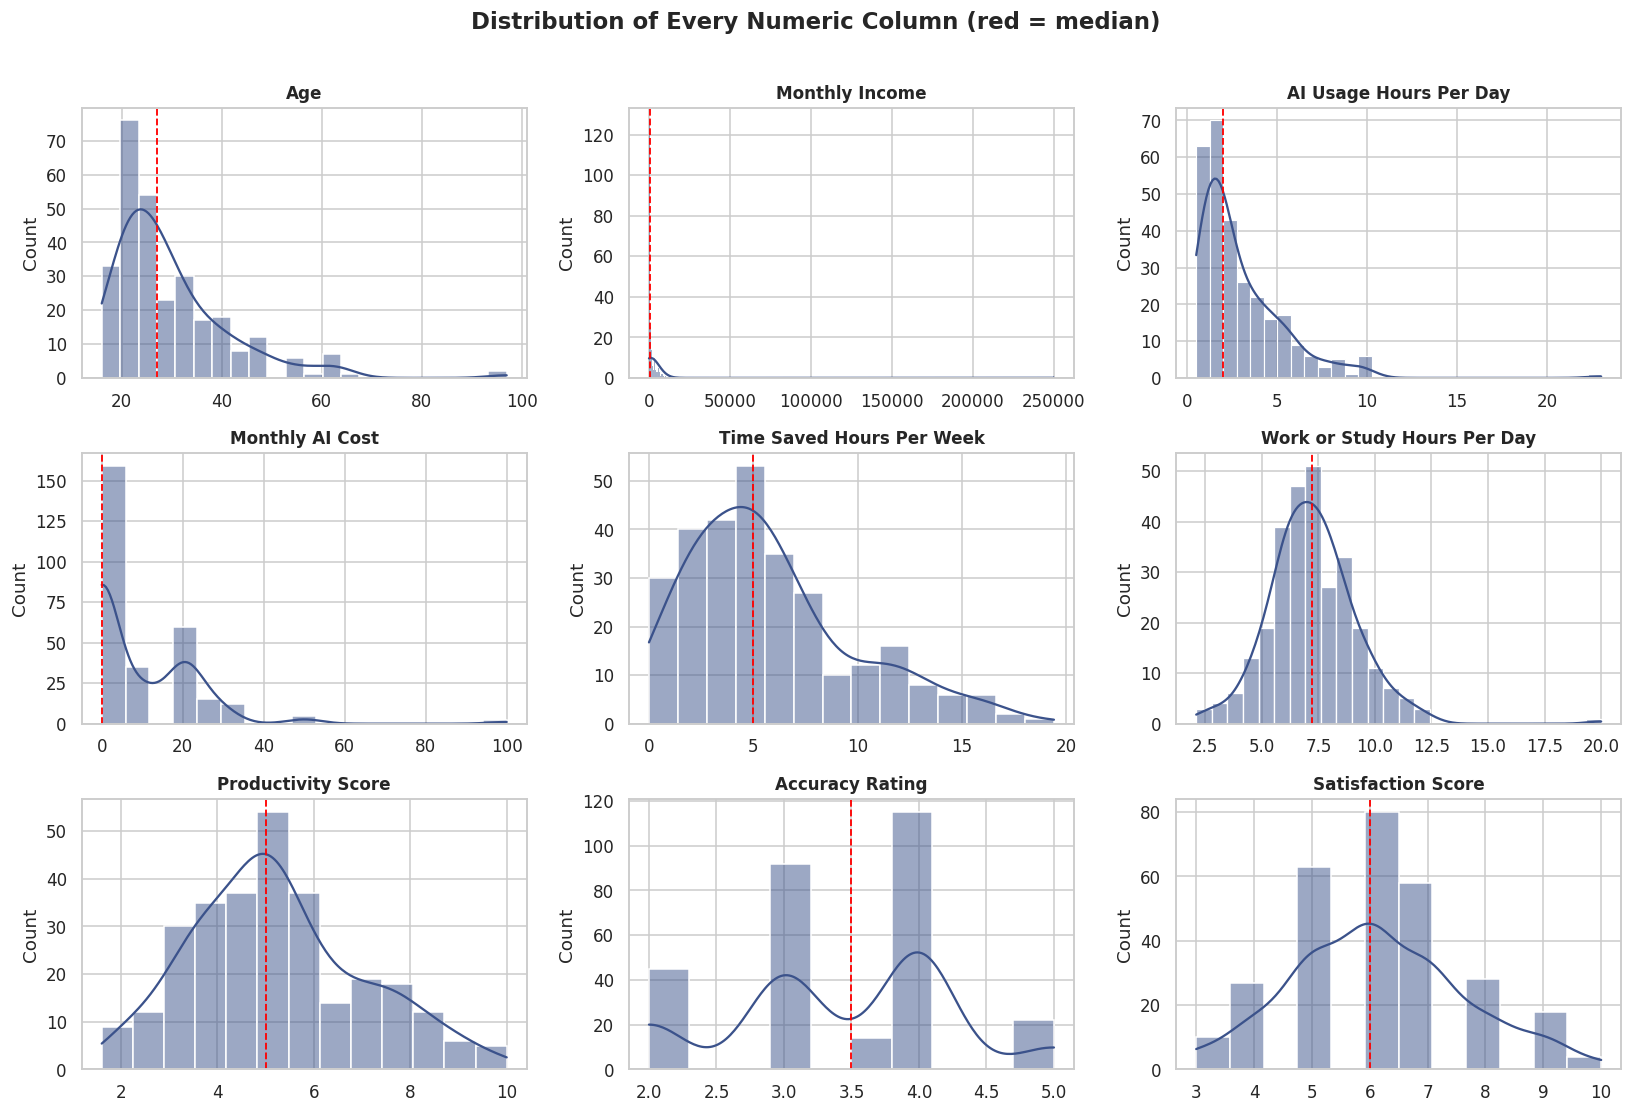

In [19]:
num_cols = ["Age", "Monthly_Income", "AI_Usage_Hours_Per_Day",
            "Monthly_AI_Cost", "Time_Saved_Hours_Per_Week",
            "Work_or_Study_Hours_Per_Day", "Productivity_Score",
            "Accuracy_Rating", "Satisfaction_Score"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="#3b528b")
    ax.axvline(df_clean[col].median(), color="red", linestyle="--", linewidth=1.2)
    ax.set_title(col.replace("_", " "), fontsize=11, fontweight="bold")
    ax.set_xlabel("")
plt.suptitle("Distribution of Every Numeric Column (red = median)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Popular vs. loved (AI tools)

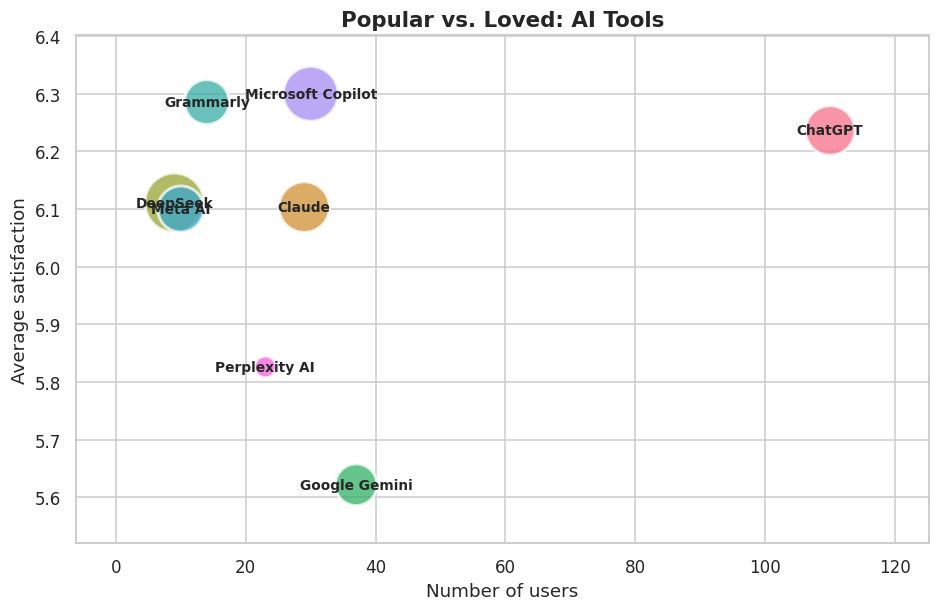

In [20]:
tools = (df_clean[df_clean["AI_Tool"] != "Unknown"]
         .groupby("AI_Tool")
         .agg(users=("User_ID", "count"),
              satisfaction=("Satisfaction_Score", "mean"),
              productivity=("Productivity_Score", "mean"))
         .query("users >= 5")          # ignore tools with too few users
         .reset_index())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tools, x="users", y="satisfaction", size="productivity",
                hue="AI_Tool", sizes=(200, 1500), alpha=0.75, legend=False)
for _, r in tools.iterrows():
    plt.text(r["users"], r["satisfaction"], r["AI_Tool"],
             ha="center", va="center", fontsize=9, fontweight="bold")
plt.title("Popular vs. Loved: AI Tools", fontsize=14, fontweight="bold")
plt.xlabel("Number of users")
plt.ylabel("Average satisfaction")
plt.margins(0.15)
plt.show()

## Is there a sweet spot for AI usage?
This groups users into usage-hour bands and checks if productivity keeps rising or levels off.

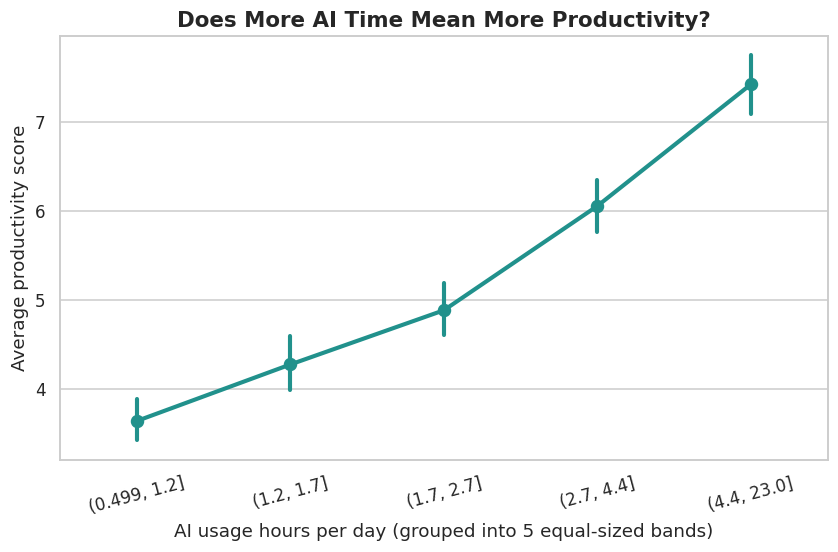

In [21]:
df_clean["Usage_Band"] = pd.qcut(df_clean["AI_Usage_Hours_Per_Day"], q=5,
                                 duplicates="drop")

plt.figure(figsize=(9, 5))
sns.pointplot(data=df_clean, x="Usage_Band", y="Productivity_Score",
              color="#21918c", markers="o", errorbar=("ci", 95))
plt.title("Does More AI Time Mean More Productivity?",
          fontsize=14, fontweight="bold")
plt.xlabel("AI usage hours per day (grouped into 5 equal-sized bands)")
plt.ylabel("Average productivity score")
plt.xticks(rotation=15)
plt.show()

## Who uses AI for what?
Each row is a profession and each cell shows what share of that profession uses AI for that purpose.

In [22]:
print(df_clean["Profession"].nunique(), "unique professions")
print(df_clean["Profession"].value_counts().head(40))

127 unique professions
Profession
English Literature Student          24
Computer Science Student            18
Unknown                             14
Biology Student                     11
Mechanical Engineering Student      10
Data Science Student                10
Content Writer                       8
Software Engineering Student         7
Software Developer                   7
Business Administration Student      6
Information Technology Student       5
Digital Marketing Student            5
Administrative Assistant             4
Data Analyst                         4
Customer Support Specialist          4
Environmental Science Student        4
Junior Software Developer            3
Senior Software Engineer             3
Business Analyst                     3
Senior Software Developer            3
Creative Writing Student             3
Research Analyst                     3
Digital Media Production Student     3
Biomedical Engineering Student       3
Content Marketing Manager     

In [23]:
def group_profession(p):
    p = str(p).lower()
    if p == "unknown":
        return "Unknown"
    if "student" in p:
        return "Student"
    if any(k in p for k in ["customer", "support", "atendimento", "kundenservice", "cliente"]):
        return "Customer Support"
    if any(k in p for k in ["data", "analyst", "analyste", "machine learning", "intelligence"]):
        return "Data & Analytics"
    if any(k in p for k in ["software", "developer", "desarrollador", "développeur",
                            "desenvolvedor", "softwareentwickler", "engineer", "information technology"]):
        return "Software & IT"
    if any(k in p for k in ["content", "marketing", "social media", "media",
                            "communications", "creator", "strategist"]):
        return "Marketing & Content"
    if any(k in p for k in ["research"]):
        return "Research"
    if any(k in p for k in ["admin", "manager", "projekt", "project"]):
        return "Admin & Management"
    return "Other"

df_clean["Profession_Group"] = df_clean["Profession"].apply(group_profession)
print(df_clean["Profession_Group"].value_counts())

Profession_Group
Student                144
Software & IT           35
Marketing & Content     30
Data & Analytics        22
Customer Support        20
Unknown                 14
Research                 9
Other                    7
Admin & Management       7
Name: count, dtype: int64


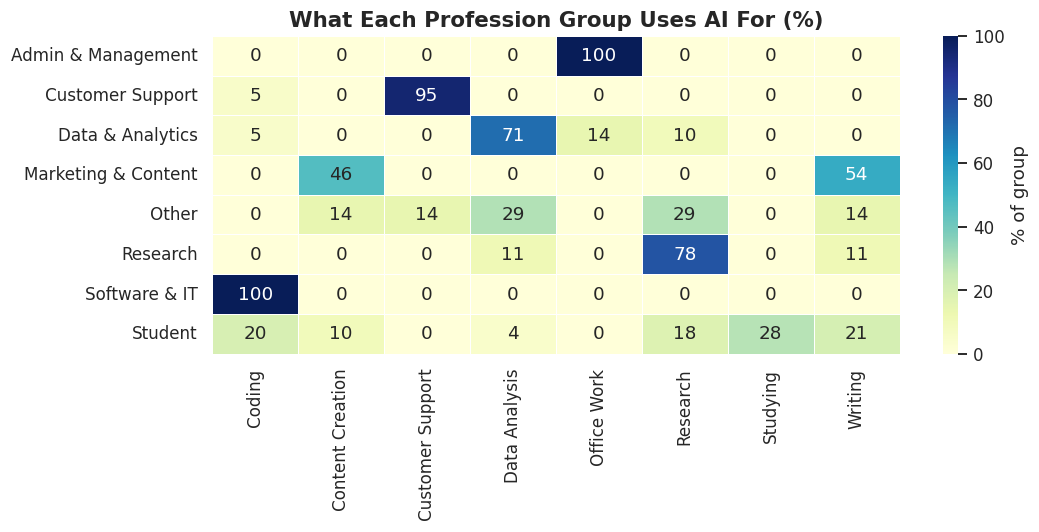

In [24]:
subset = df_clean[(df_clean["Profession_Group"] != "Unknown") &
                  (df_clean["AI_Purpose"] != "Unknown")]

heat = pd.crosstab(subset["Profession_Group"], subset["AI_Purpose"],
                   normalize="index") * 100

plt.figure(figsize=(10, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"label": "% of group"})
plt.title("What Each Profession Group Uses AI For (%)", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Does paying more buy more happiness?

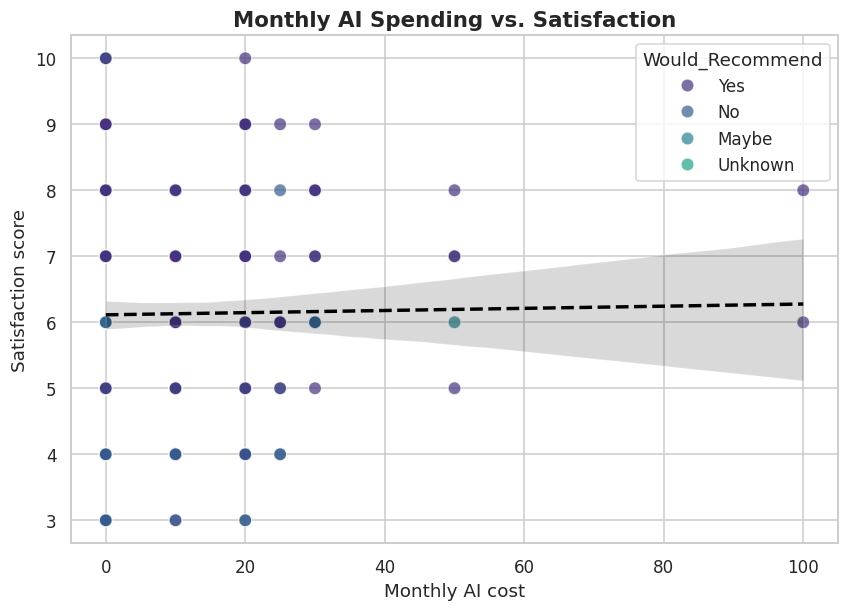

In [25]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_clean, x="Monthly_AI_Cost", y="Satisfaction_Score",
                hue="Would_Recommend", alpha=0.7, s=70)
sns.regplot(data=df_clean, x="Monthly_AI_Cost", y="Satisfaction_Score",
            scatter=False, color="black", line_kws={"linestyle": "--"})
plt.title("Monthly AI Spending vs. Satisfaction", fontsize=14, fontweight="bold")
plt.xlabel("Monthly AI cost")
plt.ylabel("Satisfaction score")
plt.show()

In [26]:
# Checking the unique values in the column
cols_to_check = ["Gender", "Country", "User_Type", "Education_Level",
                 "AI_Tool", "AI_Purpose", "Would_Recommend"]

for col in cols_to_check:
    print(f"\n===== {col} ({df_clean[col].nunique()} unique) =====")
    print(df_clean[col].value_counts())


===== Gender (12 unique) =====
Gender
Male          116
Female         99
Other          12
male           12
M              11
Unknown        10
F              10
MALE            6
FEMALE          5
other           3
female          3
Non-binary      1
Name: count, dtype: int64

===== Country (21 unique) =====
Country
India                       40
United States               33
Canada                      29
Pakistan                    28
United Kingdom              25
Philippines                 23
Brazil                      22
Australia                   19
Nigeria                     17
Germany                     13
Unknown                     10
France                       9
Kenya                        6
brazil                       4
india                        3
canada                       2
france                       1
U.K.                         1
United States of America     1
philippines                  1
australia                    1
Name: count, dtype: int64



In [27]:
print(df_clean["Tasks_Performed"].nunique(), "unique values")
print(df_clean["Tasks_Performed"].value_counts().head(25))

271 unique values
Tasks_Performed
Unknown                                                                                                                                                                                            17
Debugging code with AI assistance, generating code snippets for assignments, learning new programming languages and frameworks                                                                      2
Debugging code with AI-assisted analysis, auto-completing code functions, generating unit test cases with AI tools                                                                                  1
Literature review synthesis using AI-powered databases, data analysis and pattern identification with machine learning models, research hypothesis testing and statistical validation               1
Debugging Python code with AI assistance, generating code snippets for machine learning projects, optimizing algorithm performance, documenting technical solutions           

In [28]:
# Standarizing the values, since there are same values with just different pronounciations
# for example: United States, US
# ---- Gender ----
gender_map = {
    "male": "Male", "m": "Male",
    "female": "Female", "f": "Female",
    "other": "Other / Non-binary", "non-binary": "Other / Non-binary",
    "unknown": "Unknown",
}
df_clean["Gender"] = (df_clean["Gender"].str.strip().str.lower()
                      .map(gender_map).fillna("Unknown"))

# ---- Country ----
df_clean["Country"] = df_clean["Country"].str.strip().str.title()
df_clean["Country"] = df_clean["Country"].replace({
    "U.K.": "United Kingdom",
    "United States Of America": "United States",
})

# ---- Education_Level ----
edu_map = {
    "high school": "High School", "hs": "High School",
    "diploma": "Diploma",
    "undergraduate": "Undergraduate", "undergrad": "Undergraduate",
    "bachelor's": "Bachelor's", "bachelors": "Bachelor's",
    "bachelor's degree": "Bachelor's", "ba/bsc": "Bachelor's",
    "master's": "Master's", "masters": "Master's",
    "master's degree": "Master's", "ma/msc": "Master's",
    "phd": "PhD", "ph.d.": "PhD",
    "unknown": "Unknown",
}
df_clean["Education_Level"] = (df_clean["Education_Level"].str.strip().str.lower()
                               .map(edu_map).fillna("Unknown"))

# ---- AI_Tool ----
tool_map = {
    "chatgpt": "ChatGPT", "chat gpt": "ChatGPT",
    "claude": "Claude",
    "gemini": "Google Gemini", "google gemini": "Google Gemini",
    "copilot": "Microsoft Copilot", "microsoft copilot": "Microsoft Copilot",
    "perplexity ai": "Perplexity AI",
    "grammarly": "Grammarly",
    "meta ai": "Meta AI",
    "deepseek": "DeepSeek",
    "unknown": "Unknown",
}
df_clean["AI_Tool"] = (df_clean["AI_Tool"].str.strip().str.lower()
                       .map(tool_map).fillna("Unknown"))

In [29]:
for col in ["Gender", "Country", "Education_Level", "AI_Tool"]:
    print(f"\n===== {col} ({df_clean[col].nunique()} unique) =====")
    print(df_clean[col].value_counts())


===== Gender (4 unique) =====
Gender
Male                  145
Female                117
Other / Non-binary     16
Unknown                10
Name: count, dtype: int64

===== Country (13 unique) =====
Country
India             43
United States     34
Canada            31
Pakistan          28
United Kingdom    26
Brazil            26
Philippines       24
Australia         20
Nigeria           17
Germany           13
France            10
Unknown           10
Kenya              6
Name: count, dtype: int64

===== Education_Level (7 unique) =====
Education_Level
Bachelor's       74
Undergraduate    63
Master's         52
High School      46
Diploma          25
PhD              16
Unknown          12
Name: count, dtype: int64

===== AI_Tool (9 unique) =====
AI_Tool
ChatGPT              119
Google Gemini         39
Microsoft Copilot     33
Claude                31
Perplexity AI         23
Grammarly             14
Meta AI               10
Unknown               10
DeepSeek               9
Name:

In [30]:
task_themes = {
    "Task_Coding":      ["code", "coding", "debug", "programming", "python", "javascript",
                         "sql", "unit test", "software", "código", "codigo", "algorithm"],
    "Task_Research":    ["research", "literature", "paper", "thesis", "citation",
                         "hypothesis", "scientific"],
    "Task_Data":        ["data", "statistic", "analytics", "excel", "power bi", "spreadsheet",
                         "visualization", "dashboard", "report",
                         "análise", "analise", "tendências", "tendencias"],
    "Task_Writing":     ["writing", "essay", "blog", "grammar", "proofread", "copy",
                         "scriptwriting", "article", "email", "e-mail", "document"],
    "Task_Design_Media":["graphic", "video", "image", "design", "audio",
                         "visual content", "social media", "voiceover"],
    "Task_Studying":    ["study", "exam", "lecture", "practice question", "tutoring",
                         "learning new", "concept", "assignment", "homework"],
    "Task_Customer_Support": ["customer", "chatbot", "inquir", "ticket", "complaint",
                              "faq", "cliente", "atendimento", "kunden", "support"],
}

tasks_lower = df_clean["Tasks_Performed"].astype(str).str.lower()

for flag, keywords in task_themes.items():
    df_clean[flag] = tasks_lower.str.contains("|".join(keywords), regex=True).astype(float)

# Unknown rows stay missing, not 0
unknown_mask = df_clean["Tasks_Performed"] == "Unknown"
flag_cols = list(task_themes.keys())
df_clean.loc[unknown_mask, flag_cols] = np.nan

# Checks
no_theme = (df_clean[flag_cols].sum(axis=1) == 0) & (~unknown_mask)
print("Rows matching no theme:", no_theme.sum())
print(df_clean.groupby("AI_Purpose")[flag_cols].mean().round(2))

Rows matching no theme: 0
                  Task_Coding  Task_Research  Task_Data  Task_Writing  \
AI_Purpose                                                              
Coding                   1.00           0.00       0.15          0.42   
Content Creation         0.12           0.04       0.04          1.00   
Customer Support         0.06           0.00       0.06          0.28   
Data Analysis            0.83           0.12       1.00          0.00   
Office Work              0.20           0.10       1.00          0.90   
Research                 0.06           0.94       0.97          0.31   
Studying                 0.39           0.42       0.22          0.25   
Unknown                  0.31           0.46       0.46          0.46   
Writing                  0.00           0.58       0.04          1.00   

                  Task_Design_Media  Task_Studying  Task_Customer_Support  
AI_Purpose                                                                 
Coding            

In [31]:
# # to check if the are rows that doesn't match any theme
# no_theme = (df_clean[flag_cols].sum(axis=1) == 0) & (~unknown_mask)
# print("Rows matching no theme:", no_theme.sum())
# print(df_clean.loc[no_theme, "Tasks_Performed"].head(15).to_string())


In [32]:
# oh! so we have the above results that doesn't have any theme. From the text, it is clear that the text matches customer support theme.
# 1. New theme: customer support
support_keywords = ["customer", "chatbot", "inquir", "ticket", "complaint", "faq",
                    "cliente", "atendimento", "kunden", "support"]

tasks_lower = df_clean["Tasks_Performed"].astype(str).str.lower()
df_clean["Task_Customer_Support"] = tasks_lower.str.contains(
    "|".join(support_keywords), regex=True).astype(int)

# 2. Add a few non-English keywords to existing themes
df_clean.loc[tasks_lower.str.contains("análise|analise|tendências|tendencias|e-mail"),
             ["Task_Data"]] = 1

# 3. Unknown rows should stay missing, not 0
unknown_mask = df_clean["Tasks_Performed"] == "Unknown"
flag_cols = ["Task_Coding", "Task_Research", "Task_Data", "Task_Writing",
             "Task_Design_Media", "Task_Studying", "Task_Customer_Support"]
df_clean.loc[unknown_mask, flag_cols] = np.nan

# 4. Check again
no_theme = (df_clean[flag_cols].sum(axis=1) == 0) & (~unknown_mask)
print("Rows matching no theme:", no_theme.sum())
print(df_clean[flag_cols].sum())

Rows matching no theme: 0
Task_Coding              106.0
Task_Research             88.0
Task_Data                 97.0
Task_Writing             139.0
Task_Design_Media         39.0
Task_Studying             61.0
Task_Customer_Support     28.0
dtype: float64


In [33]:
print(df_clean.groupby("AI_Purpose")[flag_cols].mean().round(2))

                  Task_Coding  Task_Research  Task_Data  Task_Writing  \
AI_Purpose                                                              
Coding                   1.00           0.00       0.15          0.42   
Content Creation         0.12           0.04       0.04          1.00   
Customer Support         0.06           0.00       0.11          0.28   
Data Analysis            0.83           0.12       1.00          0.00   
Office Work              0.20           0.10       1.00          0.90   
Research                 0.06           0.94       0.97          0.31   
Studying                 0.39           0.42       0.22          0.25   
Unknown                  0.31           0.46       0.46          0.46   
Writing                  0.00           0.58       0.04          1.00   

                  Task_Design_Media  Task_Studying  Task_Customer_Support  
AI_Purpose                                                                 
Coding                         0.02         

# Country Comparison

In [34]:
country_df = df_clean[df_clean["Country"] != "Unknown"]

summary = (country_df.groupby("Country")
           .agg(users=("User_ID", "count"),
                usage_hrs=("AI_Usage_Hours_Per_Day", "mean"),
                time_saved=("Time_Saved_Hours_Per_Week", "mean"),
                monthly_cost=("Monthly_AI_Cost", "mean"),
                productivity=("Productivity_Score", "mean"),
                satisfaction=("Satisfaction_Score", "mean"))
           .round(2))

# Drop countries with too few users to compare fairly
summary = summary[summary["users"] >= 10].sort_values("time_saved", ascending=False)
print(summary)

                users  usage_hrs  time_saved  monthly_cost  productivity  \
Country                                                                    
Canada             31       3.64        6.45          9.52          5.68   
Australia          20       3.12        6.44          9.50          5.56   
United States      34       3.04        6.33          8.24          5.27   
Pakistan           28       3.27        6.32          8.93          5.75   
Philippines        24       2.71        6.08          9.58          5.45   
France             10       2.90        6.01          6.00          5.01   
United Kingdom     26       2.25        5.78          9.81          4.96   
Nigeria            17       3.97        5.41         12.94          4.78   
India              43       2.64        5.25         10.70          5.02   
Germany            13       2.16        4.54          8.08          4.76   
Brazil             26       2.11        4.10          8.46          4.86   

           

## Who saves the most time?

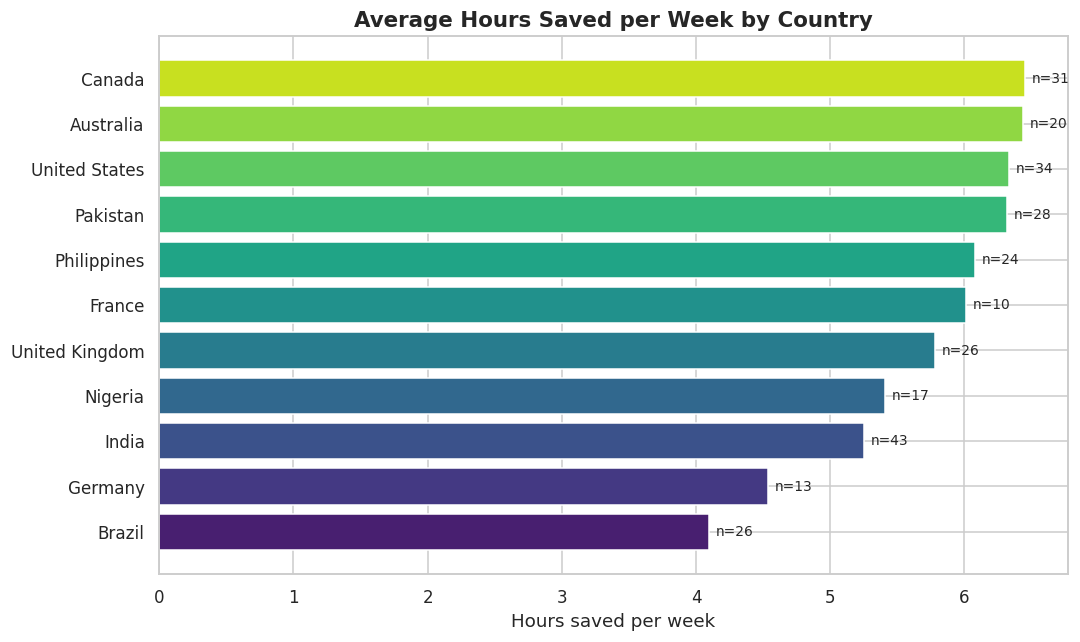

In [35]:
plt.figure(figsize=(10, 6))
bars = plt.barh(summary.index[::-1], summary["time_saved"][::-1],
                color=sns.color_palette("viridis", len(summary)))
for bar, n in zip(bars, summary["users"][::-1]):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             f"n={n}", va="center", fontsize=9)
plt.title("Average Hours Saved per Week by Country", fontsize=14, fontweight="bold")
plt.xlabel("Hours saved per week")
plt.tight_layout()
plt.show()

## Productivity vs. satisfaction (dumbbell chart)

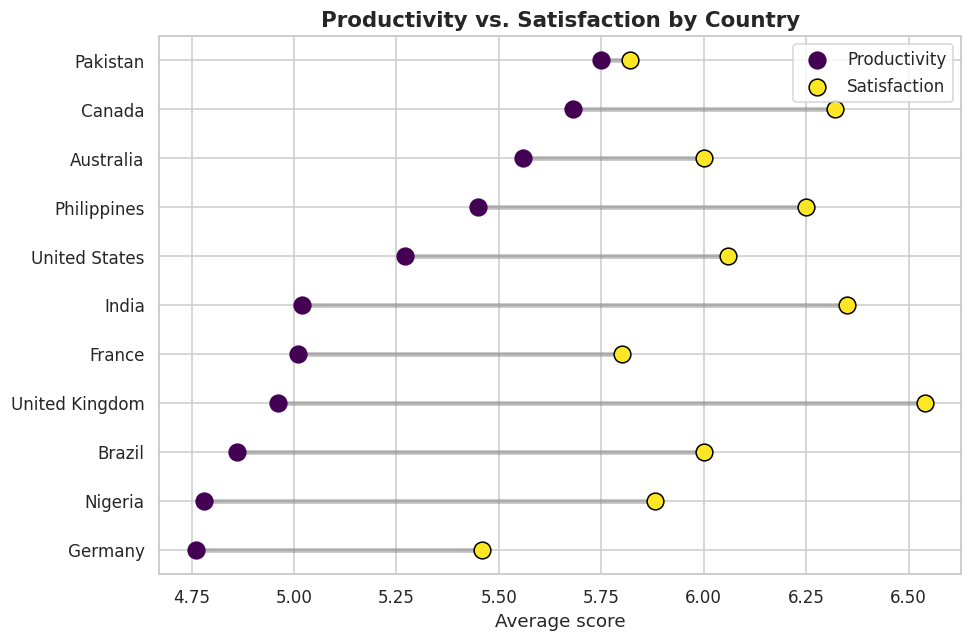

In [36]:
plot_df = summary.sort_values("productivity")

plt.figure(figsize=(9, 6))
plt.hlines(y=plot_df.index, xmin=plot_df["productivity"],
           xmax=plot_df["satisfaction"], color="grey", alpha=0.5, linewidth=3)
plt.scatter(plot_df["productivity"], plot_df.index,
            color="#440154", s=120, label="Productivity", zorder=3)
plt.scatter(plot_df["satisfaction"], plot_df.index,
            color="#fde725", s=120, edgecolor="black", label="Satisfaction", zorder=3)
plt.title("Productivity vs. Satisfaction by Country", fontsize=14, fontweight="bold")
plt.xlabel("Average score")
plt.legend()
plt.tight_layout()
plt.show()

## Who gets the most efficiency from AI?

In [37]:
# Assumption: 5 working/studying days per week
df_clean["Weekly_Work_Hours"] = df_clean["Work_or_Study_Hours_Per_Day"] * 5
df_clean["Time_Saved_Pct"] = (df_clean["Time_Saved_Hours_Per_Week"]
                              / df_clean["Weekly_Work_Hours"] * 100)

# Sanity check: saving more time than you work is impossible
print("Rows where saved time > worked time:",
      (df_clean["Time_Saved_Pct"] > 100).sum())
print(df_clean["Time_Saved_Pct"].describe().round(1))

Rows where saved time > worked time: 0
count    288.0
mean      17.2
std       14.0
min        0.0
25%        7.6
50%       14.0
75%       22.6
max       83.9
Name: Time_Saved_Pct, dtype: float64


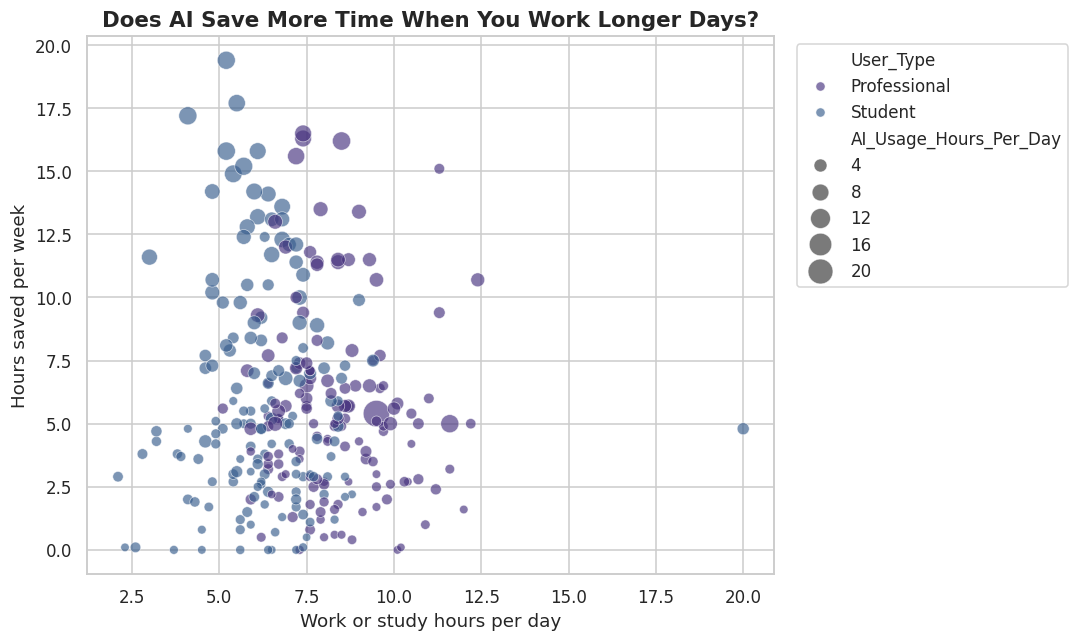

In [38]:
plot_df = df_clean[df_clean["Time_Saved_Pct"] <= 100]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="Work_or_Study_Hours_Per_Day",
                y="Time_Saved_Hours_Per_Week",
                hue="User_Type", size="AI_Usage_Hours_Per_Day",
                sizes=(30, 300), alpha=0.65)
plt.title("Does AI Save More Time When You Work Longer Days?",
          fontsize=14, fontweight="bold")
plt.xlabel("Work or study hours per day")
plt.ylabel("Hours saved per week")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Which tool gives the best time savings?

/tmp/ipykernel_16/3571947060.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tool_df, y="AI_Tool", x="Time_Saved_Pct", order=order,


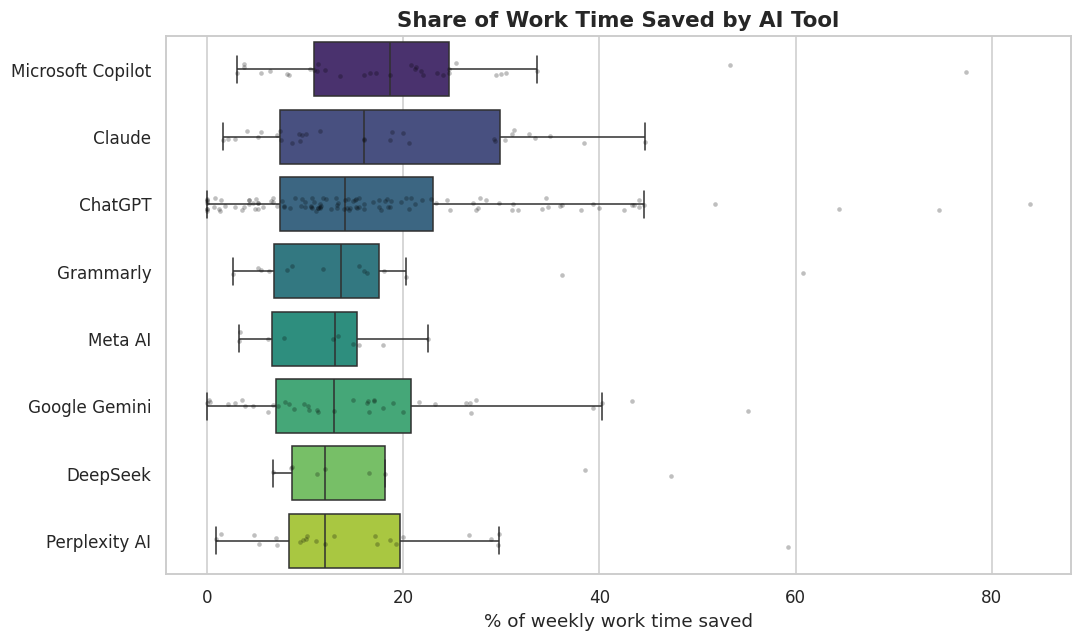

In [39]:
tool_df = plot_df[plot_df["AI_Tool"] != "Unknown"]
order = (tool_df.groupby("AI_Tool")["Time_Saved_Pct"]
         .median().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
sns.boxplot(data=tool_df, y="AI_Tool", x="Time_Saved_Pct", order=order,
            palette="viridis", showfliers=False)
sns.stripplot(data=tool_df, y="AI_Tool", x="Time_Saved_Pct", order=order,
              color="black", alpha=0.25, size=3)
plt.title("Share of Work Time Saved by AI Tool", fontsize=14, fontweight="bold")
plt.xlabel("% of weekly work time saved")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Correlation heatmap

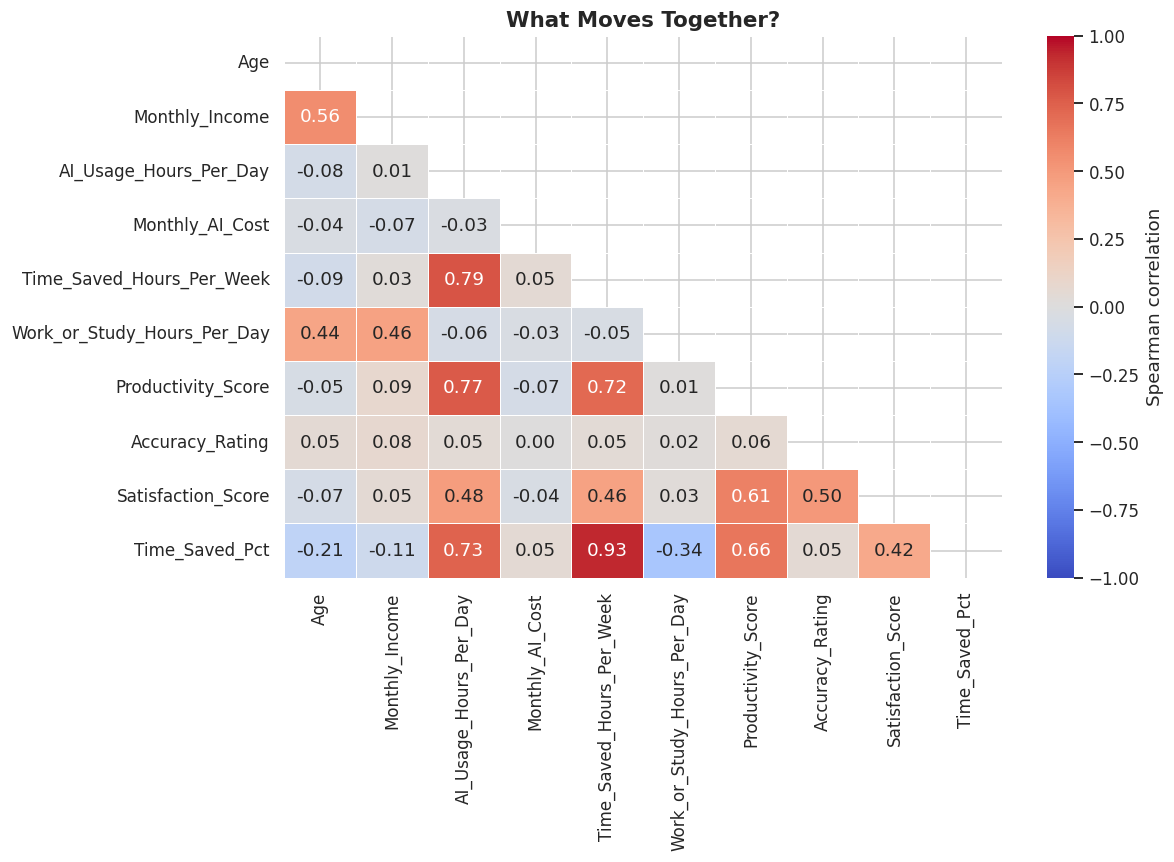

In [40]:
corr_cols = ["Age", "Monthly_Income", "AI_Usage_Hours_Per_Day",
             "Monthly_AI_Cost", "Time_Saved_Hours_Per_Week",
             "Work_or_Study_Hours_Per_Day", "Productivity_Score",
             "Accuracy_Rating", "Satisfaction_Score", "Time_Saved_Pct"]

corr = df_clean[corr_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide the duplicate half

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={"label": "Spearman correlation"})
plt.title("What Moves Together?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Clustering Users into Personas
We'll use K-Means, which groups users who look alike across several numbers. It doesn't know your persona names. It only finds the groups, and we name them afterward by looking at what each group has in common.

## Step A: Choose the features
We use numbers that describe behavior and outcomes. Two columns are transformed on purpose:

Income and cost are very skewed (a few big spenders), so we apply log1p to stop them from dominating.
User_Type is text, so we turn it into a 0/1 column.
I left out Time_Saved_Hours_Per_Week and Weekly_Work_Hours because Time_Saved_Pct already combines them. Keeping all three would count the same information twice.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

cluster_df = df_clean.copy()

cluster_df["Income_log"] = np.log1p(cluster_df["Monthly_Income"])
cluster_df["Cost_log"] = np.log1p(cluster_df["Monthly_AI_Cost"])
cluster_df["Is_Professional"] = (cluster_df["User_Type"] == "Professional").astype(int)

features = ["Age", "Income_log", "AI_Usage_Hours_Per_Day", "Cost_log",
            "Time_Saved_Pct", "Productivity_Score", "Accuracy_Rating",
            "Satisfaction_Score", "Is_Professional"]

X = cluster_df[features]
print("Missing values in features:", X.isnull().sum().sum())   # should be 0

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing values in features: 0


K-Means uses distance, so without scaling, income (in thousands) would drown out scores (1 to 10).

## Step B: Find the best number of groups

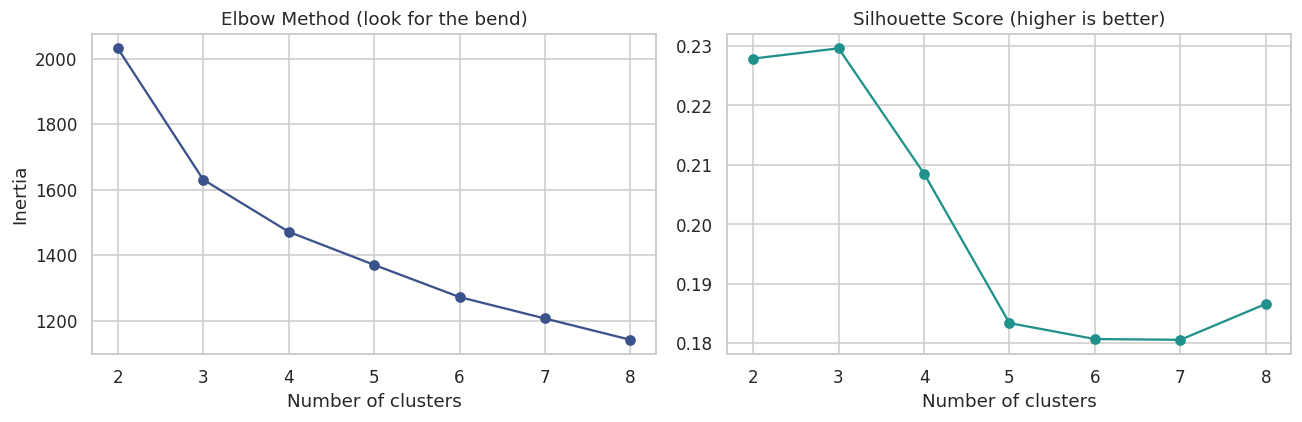

{2: np.float64(0.228), 3: np.float64(0.23), 4: np.float64(0.209), 5: np.float64(0.183), 6: np.float64(0.181), 7: np.float64(0.181), 8: np.float64(0.187)}


In [42]:
k_range = range(2, 9)
inertia, sil = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_range, inertia, marker="o", color="#3b528b")
ax[0].set_title("Elbow Method (look for the bend)")
ax[0].set_xlabel("Number of clusters")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_range, sil, marker="o", color="#21918c")
ax[1].set_title("Silhouette Score (higher is better)")
ax[1].set_xlabel("Number of clusters")
plt.tight_layout()
plt.show()

print(dict(zip(k_range, np.round(sil, 3))))

## Step C: Fit the final model


In [43]:
K = 3   # change after looking at Step B

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

print(cluster_df["Cluster"].value_counts().sort_index())

Cluster
0    118
1    107
2     63
Name: count, dtype: int64


## Step D: Profile each cluster

In [44]:
profile = cluster_df.groupby("Cluster")[
    ["Age", "Monthly_Income", "AI_Usage_Hours_Per_Day", "Monthly_AI_Cost",
     "Time_Saved_Pct", "Productivity_Score", "Accuracy_Rating",
     "Satisfaction_Score", "Is_Professional"]
].mean().round(2)
profile["size"] = cluster_df["Cluster"].value_counts().sort_index()
print(profile)

# Most common categories in each cluster
for col in ["Profession_Group", "AI_Tool", "AI_Purpose", "Country", "Would_Recommend"]:
    print(f"\n--- {col} (share of each cluster, %) ---")
    top = (pd.crosstab(cluster_df["Cluster"], cluster_df[col], normalize="index") * 100).round(0)
    print(top.apply(lambda r: r.nlargest(3).to_dict(), axis=1))

           Age  Monthly_Income  AI_Usage_Hours_Per_Day  Monthly_AI_Cost  \
Cluster                                                                   
0        38.10         4781.67                    2.14             8.01   
1        22.94          200.10                    1.85            11.73   
2        26.24         1127.13                    6.19             8.49   

         Time_Saved_Pct  Productivity_Score  Accuracy_Rating  \
Cluster                                                        
0                 10.95                4.82             3.49   
1                 13.28                4.33             3.29   
2                 35.78                7.50             3.52   

         Satisfaction_Score  Is_Professional  size  
Cluster                                             
0                      5.83             0.98   118  
1                      5.57             0.00   107  
2                      7.63             0.33    63  

--- Profession_Group (share of each c

## Step E: Visual profile

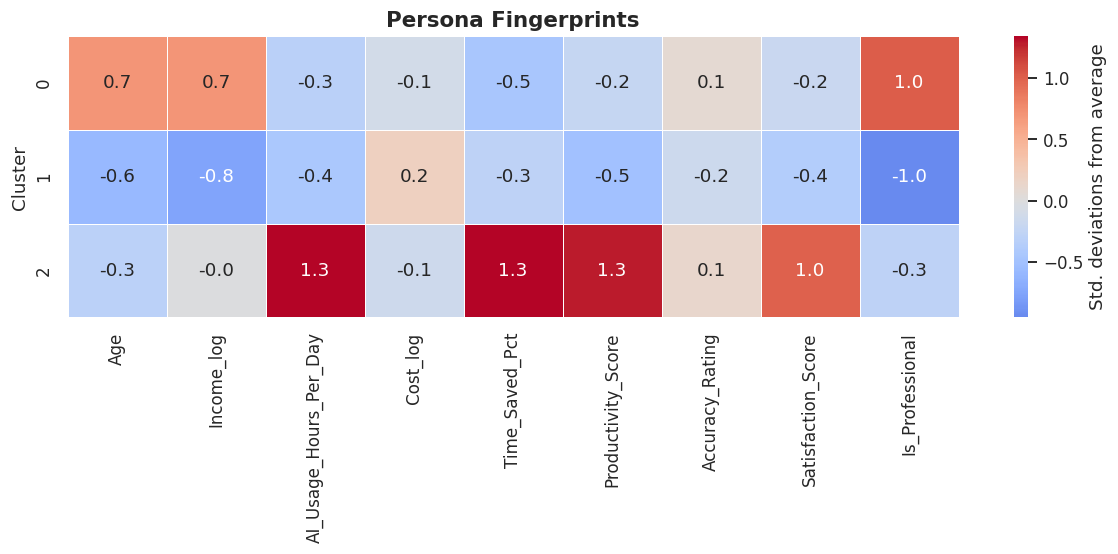

In [45]:
z = pd.DataFrame(X_scaled, columns=features)
z["Cluster"] = cluster_df["Cluster"].values
z_profile = z.groupby("Cluster").mean()

plt.figure(figsize=(11, 4 + K * 0.4))
sns.heatmap(z_profile, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Std. deviations from average"})
plt.title("Persona Fingerprints", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step F: See the clusters on a map
This squashes 9 dimensions into 2, so some overlap on the chart is normal. It doesn't mean the clusters are wrong.

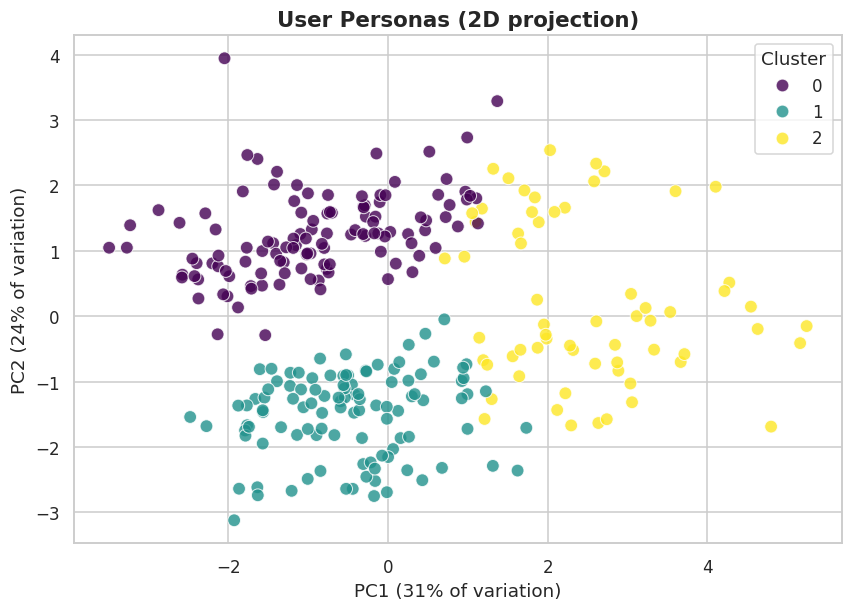

In [46]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
cluster_df["PC1"], cluster_df["PC2"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="Cluster",
                palette="viridis", s=70, alpha=0.8)
plt.title("User Personas (2D projection)", fontsize=14, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% of variation)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% of variation)")
plt.show()

## Step G: Check the groups are stable

If a different random start gives very different groups, the personas aren't reliable

In [47]:
from sklearn.metrics import adjusted_rand_score

base = cluster_df["Cluster"]
scores = []
for seed in range(1, 11):
    other = KMeans(n_clusters=K, random_state=seed, n_init=10).fit_predict(X_scaled)
    scores.append(adjusted_rand_score(base, other))
print("Stability (1.0 = identical):", np.round(np.mean(scores), 2))

Stability (1.0 = identical): 0.98


In [48]:
persona_names = {0: "Established Professionals",
                 1: "Student Explorers",
                 2: "AI Power Users"}
cluster_df["Persona"] = cluster_df["Cluster"].map(persona_names)

print(cluster_df.groupby("Persona")[["Monthly_Income", "Monthly_AI_Cost",
                                     "AI_Usage_Hours_Per_Day"]].median().round(2))

                           Monthly_Income  Monthly_AI_Cost  \
Persona                                                      
AI Power Users                      520.0              0.0   
Established Professionals          1604.0              0.0   
Student Explorers                   109.0             10.0   

                           AI_Usage_Hours_Per_Day  
Persona                                            
AI Power Users                                5.7  
Established Professionals                     1.8  
Student Explorers                             1.6  


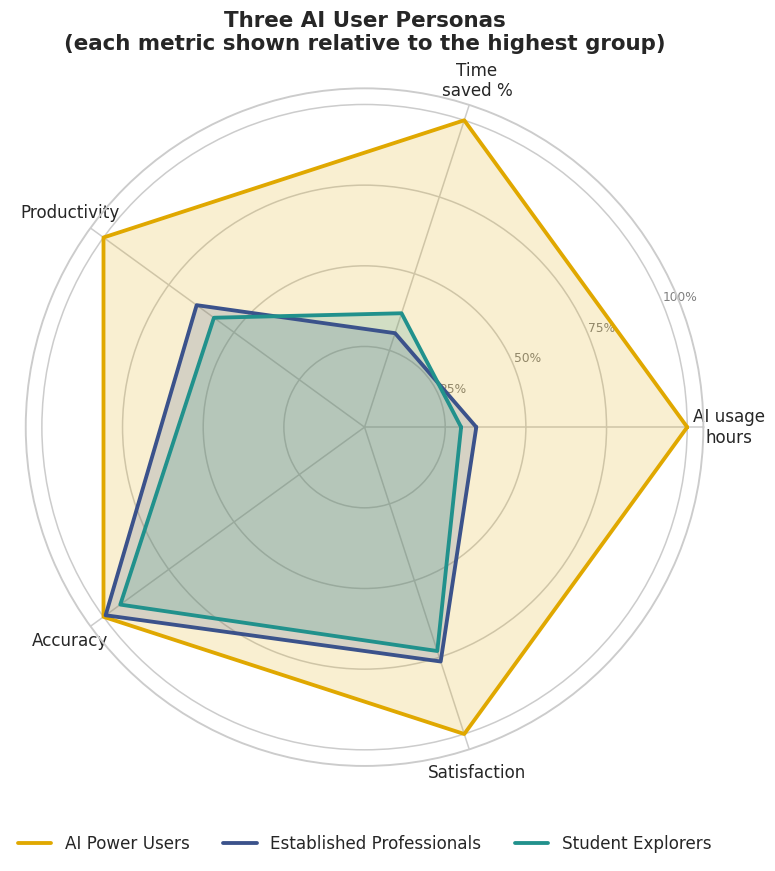

In [49]:
metrics = ["AI_Usage_Hours_Per_Day", "Time_Saved_Pct", "Productivity_Score",
           "Accuracy_Rating", "Satisfaction_Score"]
labels = ["AI usage\nhours", "Time\nsaved %", "Productivity",
          "Accuracy", "Satisfaction"]

means = cluster_df.groupby("Persona")[metrics].mean()
scaled = means / means.max()          # best group = 1.0, others relative to it

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

colors = {"Established Professionals": "#3b528b",
          "Student Explorers": "#21918c",
          "AI Power Users": "#e0a800"}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for persona, row in scaled.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, linewidth=2.5, label=persona, color=colors[persona])
    ax.fill(angles, vals, alpha=0.18, color=colors[persona])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8, color="grey")
ax.set_title("Three AI User Personas\n(each metric shown relative to the highest group)",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

plt.savefig("ai_personas_radar.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()